In [1]:
# Traditional Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score

In [2]:
dataset_sizes = [5,10,15,20,30,40,50,60,75,90,100]
iterations = 100

In [3]:
results_df = pd.DataFrame(columns=['SpearmanR Mean', 'SpearmanR Std'],index=dataset_sizes)
for size in dataset_sizes:
    np.random.seed(42)
    spearmanr_values = []
    average_precision_values = []
    y_true = np.arange(size)
    # Make sure y_true has both classes
    while len(np.unique(y_true)) < 2:
        y_true = np.random.randint(0, 2, size)
    for iteration in range(iterations):
        # Simulate some data for demonstration purposes
        y_scores = np.random.rand(size)

        # Calculate Spearman's rank correlation coefficient
        spearman_corr, _ = spearmanr(y_true, y_scores)
        spearmanr_values.append(np.absolute(spearman_corr))

    # Store the mean and std deviation of the metrics
    results_df.loc[size] = [np.mean(spearmanr_values), np.std(spearmanr_values)]

In [4]:
results_df

,SpearmanR Mean,SpearmanR Std
5,0.443,0.276498
10,0.268364,0.206691
15,0.217679,0.147406
20,0.182211,0.12873
30,0.152961,0.112448
40,0.115711,0.086563
50,0.122899,0.08996
60,0.094517,0.071371
75,0.086777,0.058769
90,0.079081,0.05856


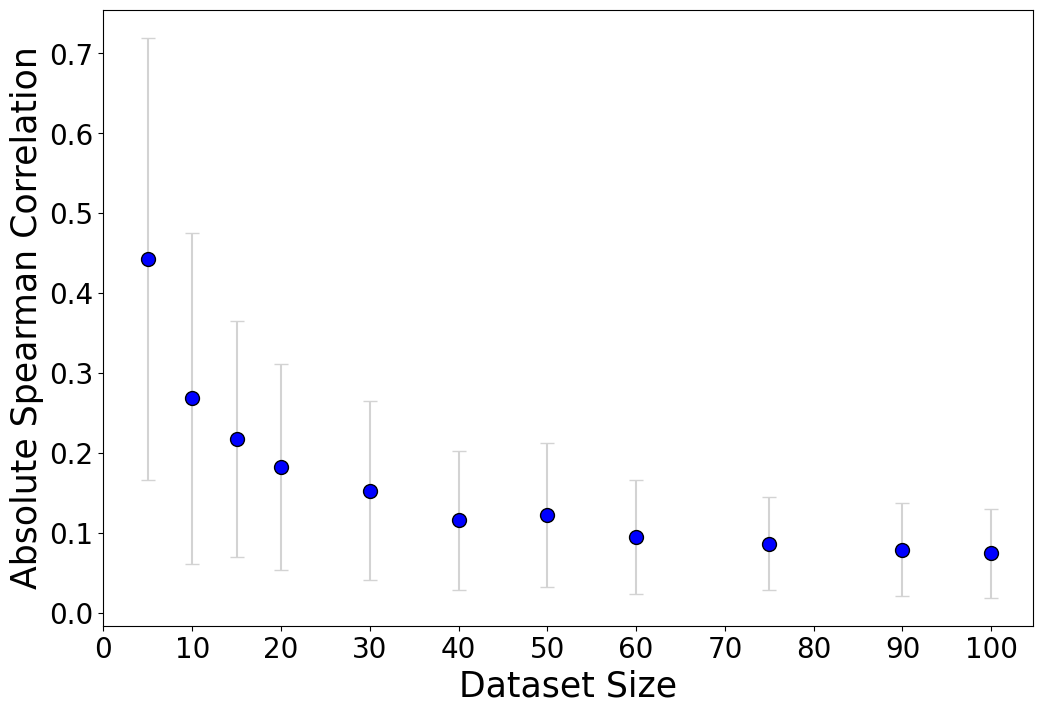

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.errorbar(results_df.index, results_df['SpearmanR Mean'], yerr=results_df['SpearmanR Std'], fmt='o', capsize=5,
            markersize=10,markerfacecolor='blue', markeredgecolor='black', ecolor='lightgray', linestyle='')
ax.set_xlabel("Dataset Size",size=25)
ax.set_ylabel("Absolute Spearman Correlation",size=25)
ax.set_xticks(np.arange(0, 110, 10))
ax.tick_params(axis='both', which='major', labelsize=20)
plt.show()

In [113]:
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score

# --- SETTINGS ---
imbalances = np.array([0.1,0.2,0.3,0.4,0.5,0.6, 0.7,0.8, 0.9])   # fraction of class 0 (negative examples)

# Create a MultiIndex DataFrame
index = pd.MultiIndex.from_product(
    [dataset_sizes, imbalances],
    names=["Dataset Size", "Class 0 Fraction"]
)
results_df = pd.DataFrame(columns=["AP Mean", "AP Std"], index=index)

# --- MAIN LOOP ---
for size in dataset_sizes:
    np.random.seed(42)
    for frac0 in imbalances:

        ap_values = []

        for _ in range(iterations):
            # Generate imbalanced labels
            n0 = int(size * frac0)
            n1 = size - n0
            y_true = np.array([0]*n0 + [1]*n1)
            np.random.shuffle(y_true)

            # Random prediction scores
            y_scores = np.random.rand(size)

            # Compute AP
            ap = average_precision_score(y_true, y_scores)
            ap_values.append(ap)

        # Store results
        results_df.loc[(size, frac0), "AP Mean"] = np.mean(ap_values)
        results_df.loc[(size, frac0), "AP Std"] = np.std(ap_values)

results_df


AP Mean    AP Std
Dataset Size Class 0 Fraction                    
5            0.1                    1.0       0.0
             0.2               0.854208  0.117455
             0.3                0.86825  0.112455
             0.4               0.707778  0.156331
             0.5               0.758333  0.152899
...                                 ...       ...
100          0.5               0.520617  0.055528
             0.6               0.417037   0.05386
             0.7               0.326902  0.046533
             0.8               0.232921  0.048599
             0.9               0.142791  0.054619

[99 rows x 2 columns]

In [126]:
heatmap_df = results_df["AP Mean"].unstack(level=1)
heatmap = np.array(heatmap_df.T.values, dtype=float)

In [127]:
heatmap_df.T

Dataset Size,5,10,15,20,30,40,50,60,75,90,100
Class 0 Fraction,,,,,,,,,,,
0.1,1.0,0.912432,0.942511,0.914966,0.911671,0.902445,0.901023,0.910778,0.908391,0.903783,0.908189
0.2,0.854208,0.848491,0.82624,0.826042,0.803773,0.82508,0.812814,0.816262,0.817638,0.805778,0.804996
0.3,0.86825,0.759293,0.770803,0.725985,0.740271,0.722222,0.72242,0.716722,0.724674,0.710735,0.715541
0.4,0.707778,0.673839,0.644863,0.646122,0.639183,0.63478,0.640892,0.626569,0.631245,0.612249,0.618276
0.5,0.758333,0.621992,0.599015,0.566755,0.546897,0.527288,0.540578,0.525692,0.540787,0.529691,0.520617
0.6,0.560667,0.528622,0.507338,0.482196,0.467081,0.448769,0.448553,0.442944,0.433735,0.427732,0.417037
0.7,0.58925,0.461618,0.465347,0.400081,0.37195,0.351539,0.349798,0.339274,0.328406,0.341644,0.326902
0.8,0.473667,0.358149,0.378704,0.305808,0.299753,0.278397,0.262614,0.250454,0.2407,0.240955,0.232921
0.9,0.4475,0.314881,0.315312,0.20427,0.171542,0.173216,0.159087,0.157412,0.15403,0.1396,0.142791


In [161]:
pos_fraction = 1-imbalances
#only keep 2 decimal places
pos_fraction = np.round(pos_fraction,2)

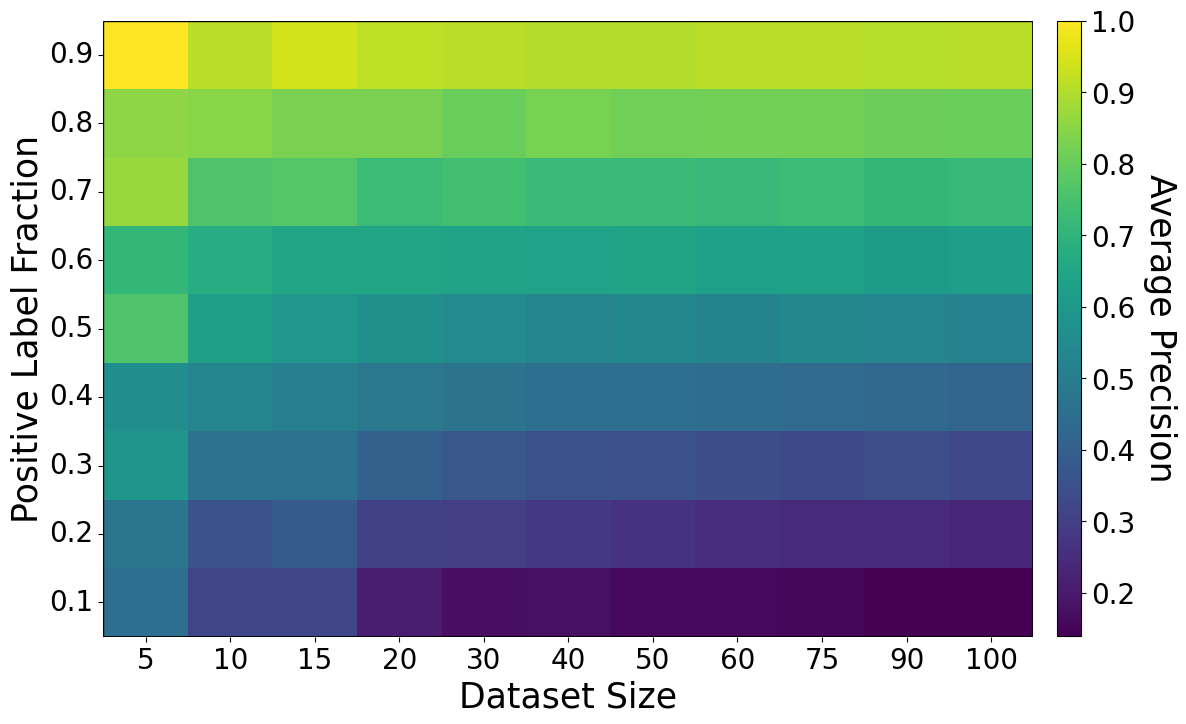

In [179]:
# Plotting the heatmap using sns
fig, ax = plt.subplots(figsize=(12, 8))
hm = sns.heatmap(heatmap, cmap="viridis", cbar=False, ax=ax)

#set ticks in the middle of each cell
ax.set_yticks(np.arange(len(imbalances)) + 0.5)
ax.set_xticks(np.arange(len(dataset_sizes)) + 0.5)
ax.set_yticklabels(pos_fraction,rotation=0)
ax.set_xticklabels(dataset_sizes)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.axhline(y=0, color='k', linewidth=1)
ax.axhline(y=len(imbalances), color='k', linewidth=2)
ax.axvline(x=0, color='k', linewidth=1)
ax.axvline(x=len(dataset_sizes), color='k', linewidth=2)

cbar_ax = fig.add_axes([0.92, 0.111, 0.02, 0.769])
cbar = fig.colorbar(hm.get_children()[0], cax=cbar_ax)
cbar.set_label('Average Precision', fontsize=25, rotation=270, labelpad=30)
cbar_ax.tick_params(labelsize=20)
ax.set_ylabel("Positive Label Fraction", size=25)
ax.set_xlabel("Dataset Size", size=25)
plt.show()